<a href="https://colab.research.google.com/github/Kaitokidbua/ASEAN_Transport/blob/main/ASEAN_Part8_EconomicGrowth_Fig27_29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ── Dark Theme ────────────────────────────────────────────────────────────────
PAPER_BG   = '#0D1117'
PLOT_BG    = '#161B22'
GRID_C     = '#30363D'
FONT_C     = '#E6EDF3'
MUTED_C    = '#8B949E'

CITY_COLORS = {
    'Bangkok':      '#FF6B6B',
    'Singapore':    '#74B9FF',
    'Kuala Lumpur': '#4ECDC4',
    'Jakarta':      '#FFB347',
    'Manila':       '#C77DFF',
}

def apply_dark_style(ax, fig, title='', xlabel='', ylabel=''):
    fig.patch.set_facecolor(PAPER_BG)
    ax.set_facecolor(PLOT_BG)
    ax.tick_params(colors=FONT_C, labelsize=10)
    ax.xaxis.label.set_color(FONT_C)
    ax.yaxis.label.set_color(FONT_C)
    ax.title.set_color(FONT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(True, color=GRID_C, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, color=FONT_C, fontsize=13, fontweight='bold', pad=12, loc='left')
    if xlabel:
        ax.set_xlabel(xlabel, color=FONT_C, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=FONT_C, fontsize=10)

def millions_fmt(x, pos):
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

def style_legend(ax, fig):
    leg = ax.get_legend()
    if leg:
        leg.get_frame().set_facecolor('#1F2937')
        leg.get_frame().set_edgecolor(GRID_C)
        for text in leg.get_texts():
            text.set_color(FONT_C)
            text.set_fontsize(9)

print('Setup complete — Dark theme (Matplotlib + Seaborn) loaded')


Setup complete — Dark theme (Matplotlib + Seaborn) loaded


In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('ASEAN_Urban_Growth_Final_with_Mode.csv')
df['Date']  = pd.to_datetime(df['Date'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# ── Mode label maps ───────────────────────────────────────────────────────────
MODE_BKK = {'BTS':'BTS Skytrain','MRT':'MRT Blue/Purple','SRT':'SRT Red Line',
             'ARL':'Airport Rail Link','YL':'MRT Yellow Line','PK':'MRT Pink Line','RL':'Regional Rail'}
MODE_SGP = {'MRT':'MRT','Public Bus':'Public Bus','LRT':'LRT'}
MODE_KL  = {
    'rail_lrt_kj':'LRT Kelana Jaya','rail_mrt_kajang':'MRT Kajang',
    'rail_lrt_ampang':'LRT Ampang','bus_rkl':'RapidKL Bus',
    'rail_mrt_pjy':'MRT Putrajaya','rail_monorail':'KL Monorail',
    'rail_komuter':'KTM Komuter','rail_komuter_utara':'KTM Utara',
    'rail_ets':'ETS Train','rail_intercity':'Intercity Rail',
    'rail_tebrau':'KTM Tebrau','bus_rkn':'RapidKN Bus','bus_rpn':'RapidPN Bus'
}
MODE_JKT = {'TRANSJAKARTA':'TransJakarta (BRT)','KRL':'KRL Commuter',
             'MRT':'MRT Jakarta','LRT':'LRT Jakarta',
             'BUS SEKOLAH':'School Bus','KCI COMMUTER BANDARA':'Airport Rail','KAPAL':'Ferry'}

print(f'Dataset: {df.shape[0]:,} rows | {df["City"].nunique()} cities')
print('Cities:', df['City'].unique().tolist())

Dataset: 2,027 rows | 5 cities
Cities: ['Bangkok', 'Jakarta', 'Kuala Lumpur', 'Singapore', 'Manila']


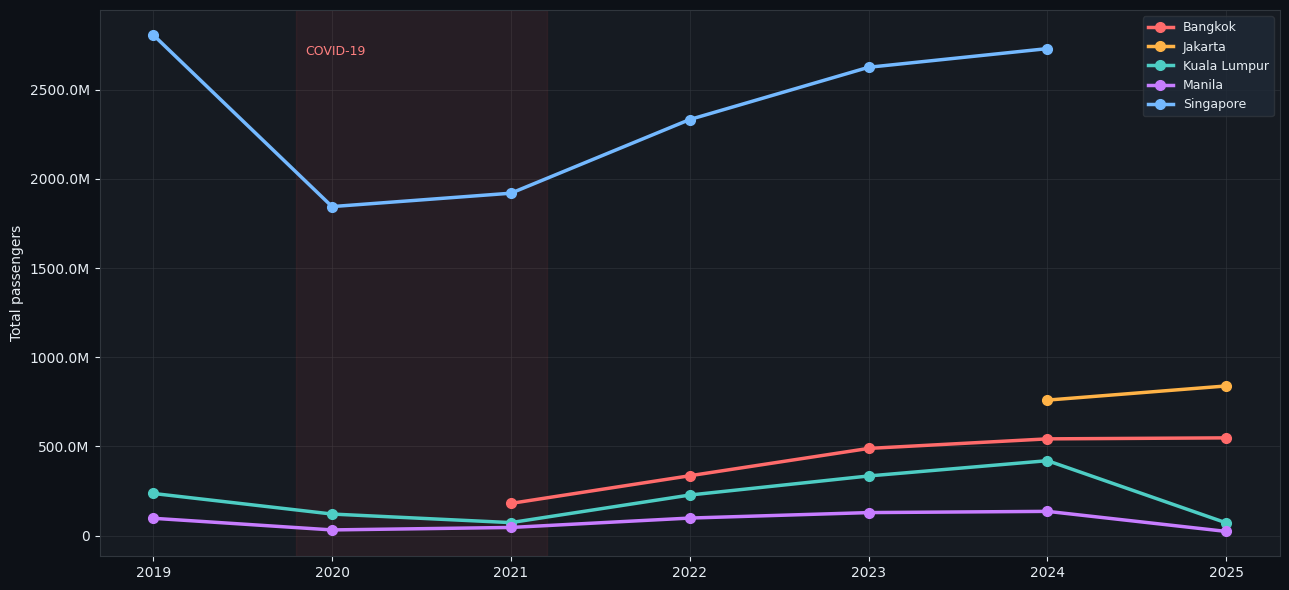

In [6]:
# ── Econ prep ──────────────────────────────────────────────────────────────────
yearly = df.groupby(['Year','City'])['Ridership'].sum().reset_index(name='Total_Ridership')
gdp_yr = df.groupby(['Year','City']).agg(
    Total_Ridership=('Ridership','sum'), GDP=('GDP_Billion_USD','mean')
).reset_index()

# ── Fig.27: Multi-city Ridership Trend ─────────────────────────────────────────
c1 = yearly[yearly['Year'].between(2019,2025)]

fig, ax = plt.subplots(figsize=(13, 6))
for city, grp in c1.groupby('City'):
    grp = grp.sort_values('Year')
    color = CITY_COLORS.get(city, '#AAAAAA')
    ax.plot(grp['Year'], grp['Total_Ridership'],
            color=color, linewidth=2.5, marker='o', ms=7, label=city)
ax.axvspan(2019.8, 2021.2, color='#FF4D4D', alpha=0.07)
ymax = c1['Total_Ridership'].max()
ax.text(2019.85, ymax*0.98, 'COVID-19', color='#FF8080', fontsize=9, va='top')
ax.yaxis.set_major_formatter(FuncFormatter(millions_fmt))
ax.set_xticks(range(2019, 2026))
apply_dark_style(ax, fig,
    title='',
    ylabel='Total passengers')
ax.legend(fontsize=9)
style_legend(ax, fig)
fig.tight_layout()
plt.show()


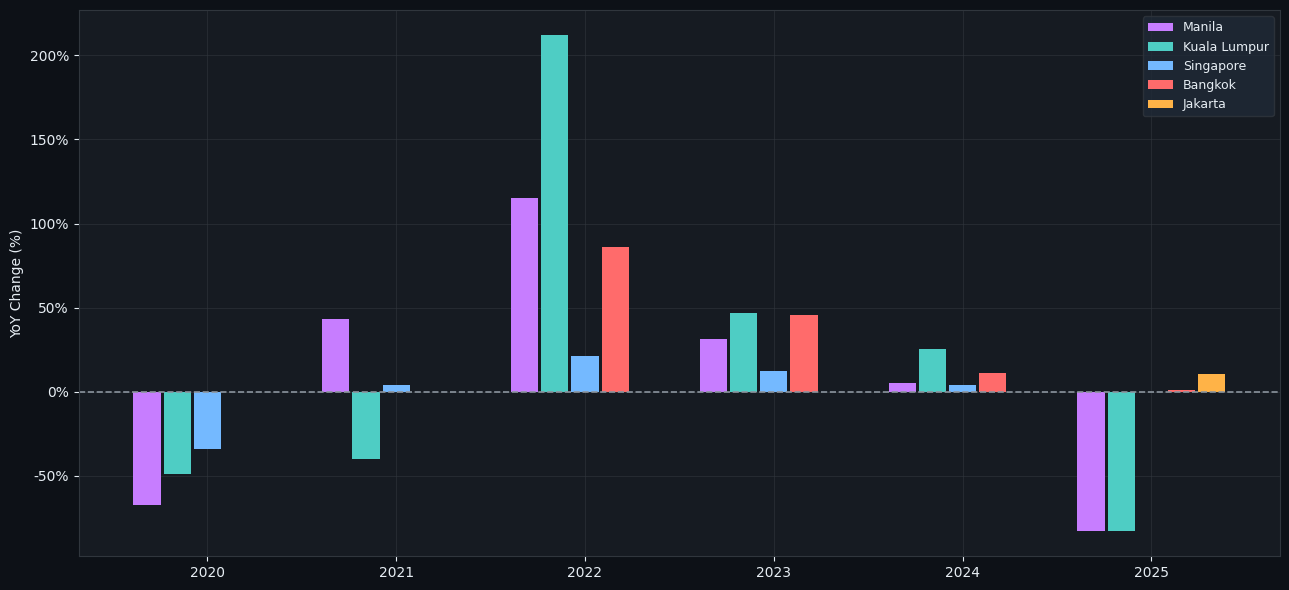

In [7]:
# ── Fig.28: YoY All Cities (Bar) ────────────────────────────────────────────────
yoy_all=[]
for city in yearly['City'].unique():
    sub = yearly[yearly['City']==city].sort_values('Year').copy()
    sub['YoY'] = sub['Total_Ridership'].pct_change()*100
    yoy_all.append(sub)
yoy_df = pd.concat(yoy_all).dropna(subset=['YoY'])
yoy_df = yoy_df[yoy_df['Year'].between(2020,2025)]

cities = yoy_df['City'].unique()
years  = sorted(yoy_df['Year'].unique())
x = np.arange(len(years))
n = len(cities)
width = 0.8 / n

fig, ax = plt.subplots(figsize=(13, 6))
for i, city in enumerate(cities):
    vals = [yoy_df[(yoy_df['Year']==y)&(yoy_df['City']==city)]['YoY'].sum() for y in years]
    ax.bar(x + i*width - (n-1)*width/2, vals, width=width*0.9,
           color=CITY_COLORS.get(city,'#AAAAAA'), label=city, edgecolor='none')
ax.axhline(0, color=MUTED_C, linestyle='--', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))
apply_dark_style(ax, fig,
    title='',
    ylabel='YoY Change (%)')
ax.legend(fontsize=9)
style_legend(ax, fig)
fig.tight_layout()
plt.show()


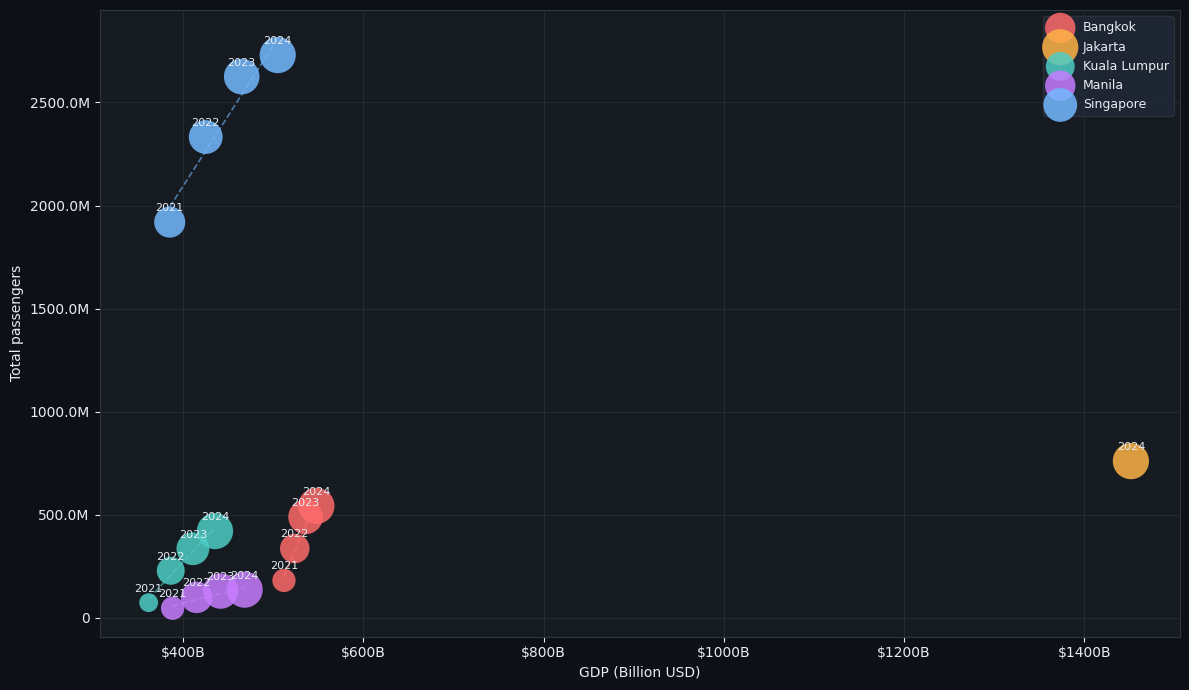

In [8]:
# ── Fig.29: Ridership vs GDP Scatter ────────────────────────────────────────────
from scipy import stats

g3 = gdp_yr[gdp_yr['Year'].between(2021,2024)].copy()

fig, ax = plt.subplots(figsize=(12, 7))
for city, grp in g3.groupby('City'):
    color = CITY_COLORS.get(city, '#AAAAAA')
    sizes = (grp['Total_Ridership'] / grp['Total_Ridership'].max()) * 600 + 80
    ax.scatter(grp['GDP'], grp['Total_Ridership'],
               s=sizes, color=color, alpha=0.85, label=city, edgecolors='none', zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(str(int(row['Year'])),
                    (row['GDP'], row['Total_Ridership']),
                    textcoords='offset points', xytext=(0,8),
                    color=FONT_C, fontsize=8, ha='center')
    if len(grp) >= 2:
        slope, intercept, r, p, se = stats.linregress(grp['GDP'], grp['Total_Ridership'])
        x_line = np.linspace(grp['GDP'].min(), grp['GDP'].max(), 50)
        ax.plot(x_line, slope*x_line + intercept, color=color, linewidth=1.2, linestyle='--', alpha=0.6)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:.0f}B'))
ax.yaxis.set_major_formatter(FuncFormatter(millions_fmt))
apply_dark_style(ax, fig,
    title='',
    xlabel='GDP (Billion USD)', ylabel='Total passengers')
ax.legend(fontsize=9)
style_legend(ax, fig)
fig.tight_layout()
plt.show()
